# Análise de dados de marketing num contexto de Marketing Mix Modeling (MMM): *Um modelo de regressão linear aplicado à mensuração de marketing*

A ideia de Marketing Mix Modeling (MMM) é usada com o objetivo de atribuir de forma justa o peso que cada canal de mídia na conversão final do usuários. Algumas ferramentas, com Google Analytics, são usadas atualmente e possuem modelos de atribuição próprios, considerando apenas canais online. O diferencial do MMM é que ele consegue integrar mídias de canais tanto online quanto offline, trazendo mais confiabilidade e conhecimento sobre o impacto real de cada canal.

**Objetivo do projeto que segue**

Estimar a contribuição de cada canal de mídia (Google, Meta e TikTok) na receita semanal de um negócio de e-commerce, simulando o raciocínio central de um modelo de MMM.

**Contexto de negócio**

Empresas que investem em múltiplos canais de mídia
simultaneamente enfrentam um desafio comum: como saber quanto cada canal
contribuiu para a receita? Este notebook constrói um modelo simples que tenta
responder essa pergunta a partir de dados históricos de investimento e receita.


**Estrutura do projeto:**

1. Geração dos dados sintéticos
2. Integração de bases com granularidades diferentes
3. Análise exploratória (EDA)
4. Preparação para modelagem
5. Regressão linear
6. Validação do modelo
7. Interpretação dos resultados



## Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np

## Criação dos datasets (com dados sintéticos)

Criamos dois datasets que simulam uma situação real de integração de dados
de marketing:

- **df_investimento:** dados diários de investimento por plataforma
  (grain: data × plataforma). Inclui sazonalidade em novembro e dezembro,
  simulando um período de alta como Black Friday.

- **df_receita:** dados de receita agregados por semana
  (grain: semana × receita total).

A escolha de grains diferentes é intencional, pois replica um problema real
em que dados de mídia chegam em granularidade diária enquanto dados
financeiros são reportados semanalmente.

Segue a tabela de investimentos.

In [ ]:
# vou criar uam base (DataFrame, já que comporta mais dimensões); uma tabela com 3 colunas: data, plataforma e investimento

np.random.seed(42) # vou usar porque vou criar valores aleatorios

# dataset 1: investimento diario por plataforma (grain: data x plataforma)
datas = pd.date_range(start = '2023-01-01', end = '2023-12-31')
plataformas = ['google', 'meta', 'tiktok']

linhas = [] # cada elemento dessa lista é um dicionario, que contem as chaves data, plataforma e random (investim) com seus respectivos valores
for data in datas:
  for plataforma in plataformas:
    fator_sazonal = 1.5 if data.month in [11, 12] else 1.0 # vou adicionar um acrescimo no orçamento de novembro e dezembor que sao meses de alta sazonalidade
    base = {'google': 1200, 'meta': 800, 'tiktok': 400} # vou adicionar essa etapa para definir uma base (um valor 'médio') que cada plataforma investe diariamente, é um chute baseado em contexto (já que google investe-se mais em geral)
    investim_ideal = base[plataforma] * np.random.uniform(0.8, 1.2) #o np.rabdom aqui, ao multiplicar, vai simular flutuações do investimento dia a dia; to chutando que pode varia de + ou - 20%
    investimento_realizado = investim_ideal * fator_sazonal
    linhas.append( {'data': data, 'plataforma': plataforma, 'investimento': round(investimento_realizado, 2) } )

df_investimento = pd.DataFrame(linhas)
df_investimento.head(3)

,data,plataforma,investimento
0,2023-01-01,google,1139.78
1,2023-01-01,meta,944.23
2,2023-01-01,tiktok,437.12


Segue a tabela de receitas.

In [ ]:
# dataset 2: tabela com receitas semanais (grain: semana)
semanas = pd.date_range(start = '2023-01-01', end = '2023-12-31', freq = 'W-MON') # adicionei o parametro de frequencia para a divisao ser em semanas

linhas_receita = []
for semana in semanas:
  fator_sazonal = 2.0 if semana.month in [11, 12] else 1.0
  investimento_semana_estimado = (1200 + 800 + 400) * fator_sazonal #adicionei para calcular a receita em cima disso
  receita = investimento_semana_estimado * 4.5 * np.random.uniform(0.85, 1.15) # estou considerando que o ROAS sera de 4.5, só pra fazer o dataset, é um chute. O np.random, vou colocar  um variação de + ou - 15% pq a agregação dos valores vai ser por semana, então os picos vão se compensando um pouco mais, chute tbm
  linhas_receita.append( {'inicio_semana': semana, 'receita': round(receita, 2) } )

df_receita = pd.DataFrame(linhas_receita)
df_receita.head(3)

,inicio_semana,receita
0,2023-01-02,9751.95
1,2023-01-09,9894.38
2,2023-01-16,9784.06


Vou fazer esse print só para ver o que está acontecendo.

In [ ]:
print("Dataset de investimento: ", df_investimento.shape)
print(df_investimento.head(3))
print("Dataset de receita: ", df_receita.shape)
print(df_receita.head(3))

Dataset de investimento:  (1095, 3)
        data plataforma  investimento
0 2023-01-01     google       1139.78
1 2023-01-01       meta        944.23
2 2023-01-01     tiktok        437.12
Dataset de receita:  (52, 2)
  inicio_semana  receita
0    2023-01-02  9751.95
1    2023-01-09  9894.38
2    2023-01-16  9784.06


## Integração dos datasets com granularidades diferentes


Um desafio real em projetos de dados de marketing é que as fontes costumam chegar em granularidades diferentes:


*   Dados de mídia: **diários** (1 linha por data × plataforma)
*   Dados de receita: **semanais** (1 linha por semana)


Fazer um join direto entre essas duas tabelas causaria duplicação da receita, com cada linha de receita sendo replicada para cada dia da semana correspondente, inflando artificialmente os valores e comprometendo o modelo.

A solução adotada foi:

1. **Agregar** o investimento diário para grain semanal usando `groupby`
   com `pd.Grouper(freq='W-MON')`, agrupando por semana com início na segunda-feira;

2. **Pivotar** o resultado para formato horizontal, com uma coluna por plataforma;

3. **Joinar** com a receita semanal pela chave `inicio_semana`.

Após o merge, verificamos a integridade dos dados: zero nulos em todas as
colunas, confirmando que a integração foi bem-sucedida.

### Etapa 1: Agregando por semana

Como cada dataset está agregado em períodos de tempo diferentes, vou optar por agregar o dataset de investimento de forma semanal para corresponder ao dataset de receitas (que já está agregado por semanas).

In [ ]:
# agregando investimento diario de forma semanal

df_investimento['data'] = pd.to_datetime(df_investimento['data']) # vou fazer isso pra garantir que o pandas vai entender essa coluna como tipo de data mesmo, e nao string

df_investimento_semanal = df_investimento.groupby( [pd.Grouper(key = 'data', freq = 'W-MON'), 'plataforma'] )['investimento'].sum()

print("Investimento semanal por plataforma: ")
print(df_investimento_semanal.head(6))

Investimento semanal por plataforma: 
data        plataforma
2023-01-02  google        2387.14
            meta          1634.16
            tiktok         782.08
2023-01-09  google        8068.55
            meta          5367.02
            tiktok        2792.89
Name: investimento, dtype: float64


Uma observação é que usei o ``pd.Grouper()`` porque o ``.groupby()``não vai dar conta nesse caso, já que, diferentemente das plataformas ( onde eu poderia usar o ``.groupby()``para agrupar), as datas são diferentes pra cada plataforma. Com o ``pd.Grouper()``, é possível passar os parâmetros de chave, indicando em cima de qual variável quero agregar, e frequência, passando que a agregação será em janelas de 1 semana (é tipo o ``DATE_TRUNC('semana', data)`` do SQL). No final uso o ``.groupby()``, realizando a agregação dos dois critérios juntos (agregação das datas e depois da plataforma).

In [ ]:
df_investimento_semanal = df_investimento.groupby( [pd.Grouper(key = 'data', freq = 'W-MON'), 'plataforma'] )['investimento'].sum().reset_index().rename( columns = {'data': 'inicio_semana'} )

print("Investimento semanal por plataforma: ")
print(df_investimento_semanal.head(5))
print("\nShape: ", df_investimento_semanal.shape)

Investimento semanal por plataforma: 
  inicio_semana plataforma  investimento
0    2023-01-02     google       2387.14
1    2023-01-02       meta       1634.16
2    2023-01-02     tiktok        782.08
3    2023-01-09     google       8068.55
4    2023-01-09       meta       5367.02

Shape:  (159, 3)


Em seguida, seleciono a coluna de ``'investimento'`` sobre a qual serão somados os valores e o retorno  do ``.groupby()`` + ``'investimento'`` + ``.sum()`` vai colocar os campos de agrupamento como índice (uma espécie de rótulo que fica fora das colunas normais), dificultado a manipulação. Para contornar isso, uso o ``.reset_index()``, que transforma tudo em colunas normais, retornando um ``DataFrame``, que é mais fácil de manipular.

Por fim (opcional), renomeio a coluna de ``'data'`` para ``'inicio_semana`` só pra indicar as semanas, que têm a data do início de cada semana.

### Etapa 2: Pivotando por plataforma

Há alguns pontos importantes que justificam a necessidade desssa etapa.



1.   O modelo de regressão que vamos construir precisa enxergar cada variável independente como uma coluna separada. Ele vai aprender: "quando investimento_google sobe, receita sobe quanto? E quando investimento_meta sobe?"

2.   Além disso, haveria um problema maior que antecederia essa etapa. Sem essa quebra por coluna, a receita apareceria três vezes (uma por plataforma) para a mesma semana, gerando duplicatas de dados e comprometendo a modelagem dos dados, já que **impediria o modelo de separar o efeito de cada canal**. O modelo não consegue separar o efeito de cada plataforma porque elas estão empilhadas numa coluna só. E o join ficaria ambíguo: cada semana teria três linhas de investimento para uma linha de receita.



In [ ]:
# pivotando plataforma  para colunas: vamor converter de 1 linha por semana por plataforma para 1 linha por semana com uma coluna por plataforma

df_investimento_pivot = df_investimento_semanal.pivot_table(index='inicio_semana', columns='plataforma', values='investimento', aggfunc='sum').reset_index()

# renomeando colunas
df_investimento_pivot.columns.name = None # estou usando o .columns.name = None porque, depois do pivot, o pandas adiciona automaticamente o nome 'plataforma' para o cjto. de colunas; adicionar essa etapa evita confusão apenas
df_investimento_pivot = df_investimento_pivot.rename(columns={ 'google': 'investimento_google', 'meta': 'investimento_meta', 'tiktok': 'investimento_tiktok'})

print("Investimento pivotado:")
print(df_investimento_pivot.head(5))
print("\nShape:", df_investimento_pivot.shape)

Investimento pivotado:
  inicio_semana  investimento_google  investimento_meta  investimento_tiktok
0    2023-01-02              2387.14            1634.16               782.08
1    2023-01-09              8068.55            5367.02              2792.89
2    2023-01-16              8405.92            5494.18              2700.50
3    2023-01-23              8160.99            5582.69              2835.87
4    2023-01-30              8472.82            5765.82              2737.30

Shape: (53, 4)


Aqui usei o ``.reset_index()`` novamente (e vou usar com frequência, por questão de praticidade para manter uma estrutura tipo DataFrame) para manter o ``inicio_semana`` como coluna comum, igual às outras.

### Etapa 3: Joinando (Merge) com a receita semanal

In [ ]:
# aqui resolvemos o problema de granularidade
# as duas tabelas agora têm a mesma grain: 1 linha por semana

df_receita['inicio_semana'] = pd.to_datetime(df_receita['inicio_semana'])
df_investimento_pivot['inicio_semana'] = pd.to_datetime(df_investimento_pivot['inicio_semana'])

df_modelo = pd.merge( df_investimento_pivot, df_receita, on='inicio_semana', how='inner') # com o 'inner join' mantemos só as semanas que existem nas 2 tabelas; semanas que existem só em uma delas são descartadas

print("\nDataset final para modelagem:")
print(df_modelo.head(5))
print("\nShape:", df_modelo.shape)


Dataset final para modelagem:
  inicio_semana  investimento_google  investimento_meta  investimento_tiktok  \
0    2023-01-02              2387.14            1634.16               782.08   
1    2023-01-09              8068.55            5367.02              2792.89   
2    2023-01-16              8405.92            5494.18              2700.50   
3    2023-01-23              8160.99            5582.69              2835.87   
4    2023-01-30              8472.82            5765.82              2737.30   

    receita  
0   9751.95  
1   9894.38  
2   9784.06  
3  11705.85  
4  10314.41  

Shape: (52, 5)


Note que na ``df_investimento_pivot``, o shape saiu 53, enquanto que na ``df_modelo`` o shape saiu 52. Isso não é erro, simplemeste é uma consequência do ``join = 'inner``, já que ele só leva em consideração as semanas que existem nas duas tabelas. Semanas que existem só em uma delas são descartadas.

Aqui vou só fazer uma checagem final para ver se há nulos (mas aqui não há).

In [ ]:
df_modelo.isnull().sum()

,0
inicio_semana,0
investimento_google,0
investimento_meta,0
investimento_tiktok,0
receita,0


## Análise Exploratória (EDA)


Antes de modelar, exploramos os dados visualmente para entender padrões,
sazonalidades e a relação entre as variáveis.

**O que buscamos responder**



*   A receita apresenta sazonalidade ao longo do ano?
*   O investimento por plataforma segue o mesmo padrão da receita?
*   Existe uma relação linear entre investimento total e receita?
*   Quão correlacionadas estão as variáveis entre si?

Vamos importar algumas bibliotecas que vão ser úteis nessa etapa.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

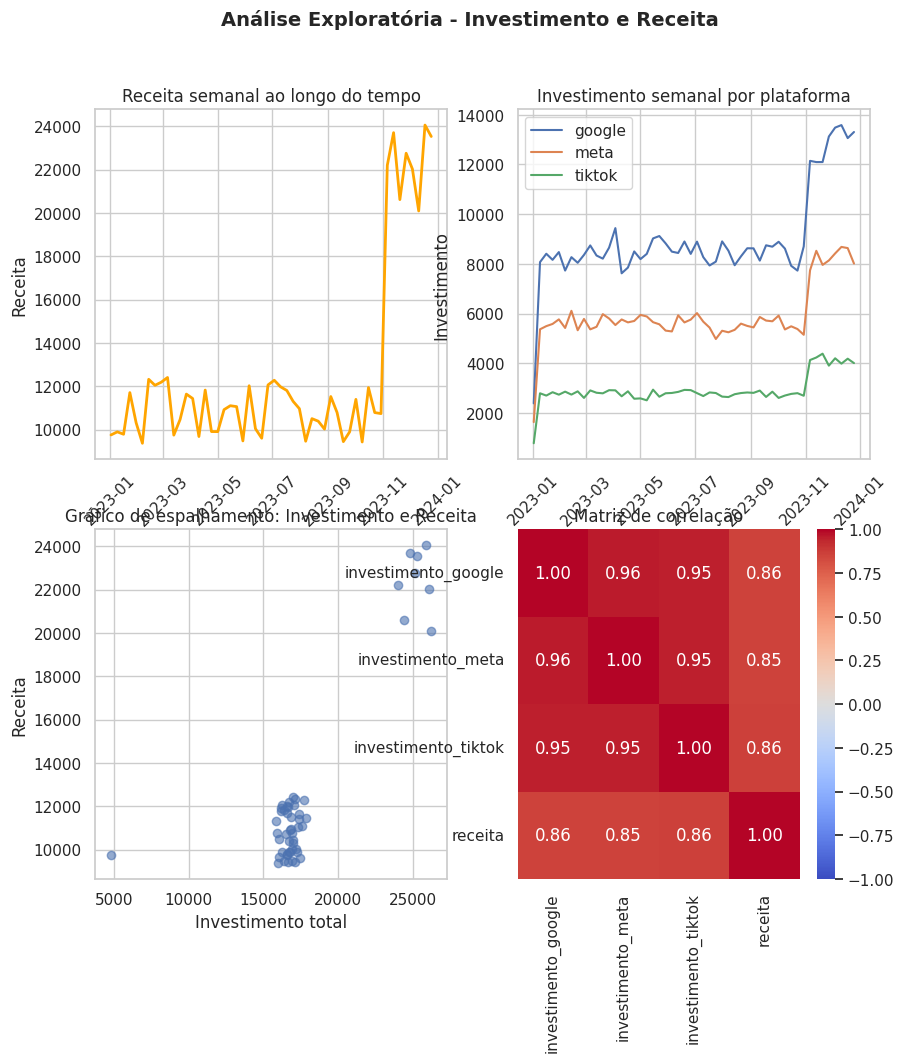

In [ ]:
# configurando a estrutura do quadro
sns.set_theme(style = 'whitegrid')
fig, axes = plt.subplots(2, 2, figsize = (10,10))
fig.suptitle('Análise Exploratória - Investimento e Receita', fontsize = 14, fontweight = 'bold')

# Gráfico 1: receita ao longo do tempo
axes[0, 0].plot(df_modelo['inicio_semana'], df_modelo['receita'], color = 'orange', linewidth = 2)
axes[0,0].set_title('Receita semanal ao longo do tempo')
axes[0,0].set_xlabel('Semana')
axes[0,0].set_ylabel('Receita')
axes[0,0].tick_params(axis = 'x', rotation = 45)

# Gráfico 2: investimento por plataforma ao longo do tempo
for col, cor in zip( ['investimento_google', 'investimento_meta', 'investimento_tiktok'], ['grey', 'pink', 'green'] ):
  axes[0,1].plot(df_modelo['inicio_semana'], df_modelo[col], label = col.replace('investimento_', ''), linewidth = 1.5 )
axes[0,1].set_title('Investimento semanal por plataforma')
axes[0,1].set_xlabel('Semana')
axes[0,1].set_ylabel('Investimento')
axes[0,1].legend()
axes[0,1].tick_params(axis = 'x', rotation = 45)

# Gráfico 3: correlação entre investimento e receita
df_modelo['investimento_total'] = (df_modelo['investimento_google'] + df_modelo['investimento_meta'] + df_modelo['investimento_tiktok']) # eu vou definir essa variavel aqui pra ficar mais facil
# vou plotar o espalhamento para ver graficamente se há correlação de fato entre as duas variáveis
axes[1,0].scatter(df_modelo['investimento_total'], df_modelo['receita'], alpha = 0.6) # coloquei 0.6 só pra controlar a opacidade na sobreposição de pontos
axes[1,0].set_title('Gráfico de espalhamento: Investimento e Receita')
axes[1,0].set_xlabel('Investimento total')
axes[1,0].set_ylabel('Receita')

# Gráfico 4: Matriz de correlação
corr = df_modelo[ ['investimento_google', 'investimento_meta', 'investimento_tiktok', 'receita'] ].corr()
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', ax = axes[1,1], vmin = -1, vmax = 1) #annot exibe os numeros dentro das celulas; vim e max evitam a normalização nas cores a partir dos valores
axes[1,1].set_title('Matriz de correlação')

plt.tight_layout
plt.show()

**Principais observações:**



*   **Sazonalidade clara:** receita e investimento apresentam pico expressivo
  em novembro e dezembro, com receita chegando a 24.000 reais, quase o dobro
  da mediana de 11.000 reais nas semanas normais.
*   **Relação linear:** o espalhamento do investimento total vs. receita confirma uma relação linear positiva, o que valida o uso de regressão linear como   abordagem de modelagem.

> No gráfico de espalhamento abaixo, cada ponto representa uma semana.
O eixo horizontal mostra o investimento total naquela semana, e o eixo
vertical mostra a receita. Se os pontos formam uma diagonal (subindo da
esquerda para a direita) a relação é linear positiva.
>
> Isso importa porque a regressão linear é exatamente o modelo matemático
que encontra a "linha que melhor passa por esses pontos". Se os pontos
não formassem uma diagonal (se estivessem espalhados aleatoriamente)
a regressão linear não funcionaria bem. O gráfico nos dá confiança de que
a abordagem escolhida é adequada para esses dados.
>
>*Observação:* é possível notar dois grupos de pontos separados: as semanas
normais (investimento entre 14-18k reais, receita entre 10-12k reais) e as semanas de novembro/dezembro (investimento entre 22-26k reais, receita entre 20-24k reais). Ambos os grupos seguem a mesma tendência linear, o que reforça a validade do modelo.

*   **Multicolinearidade:** a matriz de correlação revela correlação muito alta
  entre as plataformas (0.95–0.96). Como todas seguem a mesma sazonalidade,
  o modelo terá dificuldade de separar o efeito individual de cada canal com
  precisão (uma limitação esperada).

>Um pouco mais sobre Multicolinearidade:
>
> Multicolinearidade ocorre quando duas ou mais variáveis
independentes se movem juntas de forma muito parecida.
>
>Nos dados deste projeto, Google, Meta e TikTok sobem e
descem juntos, já que todos seguem a mesma sazonalidade de novembro e dezembro.
Quando um aumenta, os outros também aumentam. O modelo nunca observa um
canal subindo enquanto os outros ficam parados.
>
>A consequência prática é que o modelo consegue prever bem a receita total, mas tem dificuldade de dizer com precisão quanto veio do Google e quanto veio
do Meta, porque nos dados históricos eles sempre se comportaram igual.
>
>Na matriz de correlação, isso aparece como valores próximos de 1 entre
as plataformas (0.95–0.96). Valores acima de 0.9 entre variáveis independentes
são um sinal de alerta de multicolinearidade.
>
>*Como resolver em modelos mais avançados*
>Em modelos reais de MMM, esse problema é tratado com técnicas como:
>Inclusão de variáveis de sazonalidade explícitas (ex: dummy para novembro/dezembro);
>Transformações de adstock, que modelam o efeito acumulado da mídia ao longo do tempo;
>Regularização (Ridge, Lasso), que penaliza coeficientes muito grandes causados por multicolinearidade.
>
>Aqui estou usando regressão linear simples como ponto de partida, e a
multicolinearidade identificada aqui seria o próximo problema a resolver
numa evolução do modelo.


Agora, vamos usar o ``.describe()`` para ver o valor das métricas centrais:

In [ ]:
# estatísticas descritivas
print("Estatísticas descritivas:")
print(df_modelo[['investimento_google', 'investimento_meta', 'investimento_tiktok', 'receita']].describe().round(2))

Estatísticas descritivas:
       investimento_google  investimento_meta  investimento_tiktok   receita
count                52.00              52.00                52.00     52.00
mean               8988.89            5921.60              2941.96  12581.38
std                1914.72            1177.01               591.72   4344.24
min                2387.14            1634.16               782.08   9367.41
25%                8183.53            5409.76              2698.64   9906.69
50%                8494.68            5649.18              2804.74  11080.30
75%                8894.61            5921.44              2909.25  12047.49
max               13581.33            8680.54              4386.15  24053.52


A receita apresenta média de 12.581 reais e desvio padrão de 4.344 reais,
variação alta em relação à média, reflexo direto da sazonalidade de
novembro e dezembro. O valor máximo de 24.053 reais é quase o dobro da
mediana de 11.030 reais, confirmando que as semanas de alta sazonalidade
se comportam como outliers positivos em relação ao restante do ano.

O Google concentra o maior investimento médio semanal (8.989),
seguido de Meta (5.922) e TikTok (2.942), mas como veremos
na interpretação do modelo, investimento maior não significa
necessariamente maior eficiência por real investido.

## Preparação para modelagem


Antes de treinar o modelo, separamos os dados em dois conjuntos:



*   **Treino (80%):** 41 semanas, usadas para o modelo aprender os padrões.
*   **Teste (20%):** 11 semanas, reservadas para avaliar se o modelo
  generaliza bem para dados que nunca viu.


-

**Por que essa divisão é necessária?**

Um modelo treinado e avaliado nos mesmos dados pode simplesmente
memorizar as respostas em vez de aprender o padrão real. Separar
treino e teste garante uma avaliação honesta da capacidade preditiva
do modelo.

Aqui, teremos **X (variáveis independentes)** que correspondem à investimento_google, investimento_meta, investimento_tiktok e **y (variável dependente)** que é a receita.

Primeiro vou precisar importar recursos de algumas bibliotecas.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Agora vamos definir as variáveis independentes e dependentes.

In [ ]:
# investimento é a variável independente
X = df_modelo[ ['investimento_google', 'investimento_meta', 'investimento_tiktok'] ]
# receita é a variavel dependente
Y = df_modelo['receita']

Note que o ``X`` é um ``DataFrame`` e o ``Y`` é uma ``Series``.

#### Reprodutibilidade



Agora vamos dividir a base de treino e a base de teste.

In [ ]:
# vou dividir 20% das semanas para a base de teste e os outros 80% das semanas ficam para treino
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = 0.2, random_state = 42)

Aqui o ``random_state = 42`` garante reprodutibilidade; toda vez que rodar o código, a divisão das bases será a mesma (terá os mesmos valores). Sem isso, a divisão seria aleatória a cada execução e os resultados mudariam.

Vou printar cada base só para ver como ficou.

In [ ]:
print("Shape X_treino: ", X_treino.shape)
print("Shape X_teste: ", X_teste.shape)
print("Shape Y_treino: ", Y_treino.shape)
print("Shape Y_teste: ", Y_teste.shape)

print("\nSemanas no treino: ", X_treino.shape[0])
print("Semanas no teste: ", X_teste.shape[0])

Shape X_treino:  (41, 3)
Shape X_teste:  (11, 3)
Shape Y_treino:  (41,)
Shape Y_teste:  (11,)

Semanas no treino:  41
Semanas no teste:  11


Só a título de curiosidade, o ``.shape`` retorna uma tupla, retornando linhas e colunas no caso de X (que é um DataFrame) e só linhas com uma coluna no caso de Y (que é uma Series). Usamos o ``.shape[0]`` porque queremos printar só o número de semanas (que é o número de linhas), sem aparecer o número de colunas junto.

## Treinamento do modelo: Regressão linear

Nessa etapa, vamos treinar o modelo. Aqui o modelo vai "aprender" o coeficiente de cada plataforma, quanto cada R$1 investido gera de receita. Vamos ver se ele chega próximo do ROAS de 4.5 que definimos na criação dos dados.

A regressão linear múltipla encontra os coeficientes que melhor explicam
a relação entre as variáveis independentes (investimentos) e a variável
dependente (receita).



In [ ]:
modelo = LinearRegression()
modelo.fit(X_treino, Y_treino)

LinearRegression()

Quando criamos o ``modelo = LinearRegression()``, criamos um objeto do scikit-learn que tem propriedades internas. Depois disso, chamamos o ``.fit()``, o objeto ``modelo`` (criado pela ``LinearRegression()``) guarda os resultados internamente em atributos com nomes personalizados, chamados *intercepto* e *coeficientes*.

Aqui o ``.fit()`` recebe os dados de treino e ajusta os coeficientes internos para minimizar o erro entre o que ele prevê e o que realmente aconteceu. É o equivalente matemático de traçar a linha que melhor passa pelos pontos do scatter que vimos na parte da análise descritiva.


Sendo assim, os atributos do ``modelo`` representam o que o modelo aprendeu sobre a relação entre Investimento e Receita. Se formos escrever a equação matemática para o modelo atual, ela é da forma:

````
y = a1x1 + a2x2 + a3x3 + constante
````

ou mais precisamente:

````
receita = coef_1 x inv_google x  + coef_2 x inv_meta + coef_3 x inv_tiktok + intercepto
````

Os valores intercepto e os demais coeficientes são armazenados nas variáveis, respectivamente, ``modelo.intercept_``, sendo este um valor constante, e ``modelo.coef_``, sendo este um array com os coeficientes de cada variável independente, na mesma ordem das colunas de X. Só lembrando um pouco de POO, o underscore (_) no final é uma convenção do scikit-learn para indicar que aquele atributo só existe depois do ``.fit()``, ou seja, antes de treinar, ele não existia ainda.

In [ ]:
print("Intercepto: ", round(modelo.intercept_, 2) )
print("\nCoeficientes por plataforma: ")

df_coeficientes = pd.DataFrame( {'plataforma': X.columns.tolist(), 'coeficiente': modelo.coef_.round(4)} )
print(df_coeficientes)

Intercepto:  -4492.17

Coeficientes por plataforma: 
            plataforma  coeficiente
0  investimento_google       0.5835
1    investimento_meta       0.1666
2  investimento_tiktok       3.6766


A equação do modelo é:

``receita = -4.492 + 0,58 × inv_google + 0,17 × inv_meta + 3,68 × inv_tiktok``

**Interpretação dos coeficientes:**



*   Para cada 1 real investido no Google, o modelo estima 0,58 de receita adicional;
*   Para cada 1 real investido no Meta, o modelo estima 0,17 de receita adicional;
*   Para cada 1 real investido no TikTok, o modelo estima 3,68 de receita adicional.


**Atenção — efeito da multicolinearidade:**

Esses coeficientes estão influenciados pela multicolinearidade identificada
na Análise Exploratória. Como as três plataformas seguem a mesma sazonalidade, o modelo distribui o crédito de forma desequilibrada entre elas.

## Validação do modelo


Aqui vamos calcular métricas de erro: R², MAE e RMSE e verificar se o modelo performa bem nos dados de teste (aqueles que ele nunca viu durante o treino).

Vejamos o que significa cada métrica.

**R²: indica o quanto o modelo explica.**

Vai de 0 a 1. Um R² de 0.85 significa que o modelo explica 85% da variação da receita. O restante 15% é explicado por fatores que o modelo não capturou: sazonalidade não modelada, eventos externos, ruído. Para um modelo simples de regressão linear com 3 variáveis, R² acima de 0.80 já é considerado bom.


**MAE: é o erro médio absoluto.**

É a diferença média em reais entre o que o modelo previu e o que aconteceu de verdade. Se MAE = 800 reais, significa que em média o modelo erra 800 reais por semana. Essa variável é mais fácil de interpretar para um cliente não-técnico.


**RMSE: é raiz do erro quadrático médio.**

Parecido com o MAE, mas penaliza erros grandes mais do que erros pequenos. Se o RMSE for muito maior que o MAE, significa que o modelo tem algumas semanas com erro muito alto, o que pode indicar que as semanas de sazonalidade forte estão sendo mal previstas.




In [ ]:
# essa variável guarda os valores que o modelo prevê para as 11 semanas do teste; o modelo vai prever com base no X_teste
Y_previsto = modelo.predict(X_teste)

# calculando métricas
r2 = r2_score(Y_teste, Y_previsto)
mae = mean_absolute_error(Y_teste, Y_previsto)
rmse = np.sqrt(mean_squared_error(Y_teste, Y_previsto))

print("Métricas de validação — dados de teste:")
print(f"  R²:   {round(r2, 4)}")
print(f"  MAE:  R$ {round(mae, 2)}")
print(f"  RMSE: R$ {round(rmse, 2)}")

# comparando previsto vs real
df_validacao = pd.DataFrame({
    'receita_real': Y_teste.values,
    'receita_prevista': Y_previsto.round(2),
    'erro_absoluto': abs(Y_teste.values - Y_previsto).round(2),
    'erro_pct': (abs(Y_teste.values - Y_previsto) / Y_teste.values * 100).round(1)
})

print("\nComparação previsto vs real (primeiras 10 semanas de teste):")
print(df_validacao.head(10))

Métricas de validação — dados de teste:
  R²:   0.8392
  MAE:  R$ 1475.4
  RMSE: R$ 1955.8

Comparação previsto vs real (primeiras 10 semanas de teste):
   receita_real  receita_prevista  erro_absoluto  erro_pct
0      11101.13          12518.03        1416.90      12.8
1      11937.91          11220.85         717.06       6.0
2      22753.54          18877.79        3875.75      17.0
3      11636.69          12249.23         612.54       5.3
4      10737.10          11343.86         606.76       5.7
5       9367.41          11433.17        2065.76      22.1
6       9905.17          10790.10         884.93       8.9
7      24053.52          19949.39        4104.13      17.1
8      11705.85          11626.33          79.52       0.7
9      10503.39          11164.19         660.80       6.3


Interpretando os dados:

**R² = 0.8392**

O modelo explica 84% da variação da receita, o que é bom para um modelo simples de regressão linear com apenas 3 variáveis. Os 16% restantes são ruído e sazonalidade que o modelo não capturou completamente.


**MAE = 1.475 reais**

Em média, o modelo erra 1.475 reais por semana. Olhando a tabela, a receita média é em torno de 12.000 reais, então o erro médio é cerca de 12% do valor real. Aceitável para um modelo de primeira versão.


**RMSE = 1.955 reais**

O RMSE é bem maior que o MAE, isso confirma a seguinte suspeita: algumas semanas têm erros grandes que puxam o RMSE para cima. Olhando a linha 2 da tabela:  receita real de 22.753 e prevista de 18.877 reais, erro de 3.875 reais (17%). E a linha 8: receita real de 24.053 reais e prevista de 19.949 reais, erro de 4.104 reais (17%). Essas são semanas de novembro/dezembro (o modelo subestima os picos de sazonalidade).



**Observação importante:**

O modelo performa bem nas semanas normais (erros de 5-6%) mas subestima as semanas de alta sazonalidade (erros de 17-22%). Isso sugere que um modelo mais sofisticado poderia incluir uma variável de sazonalidade explícita, como um indicador de mês ou uma dummy para novembro/dezembro.

**O gráfico de previsto vs real:**

A linha vermelha tracejada representa a previsão perfeita, onde previsto = real. Quanto mais próximos os pontos estiverem dessa linha, melhor o modelo. Pontos muito acima ou abaixo dela são semanas onde o modelo errou bastante.

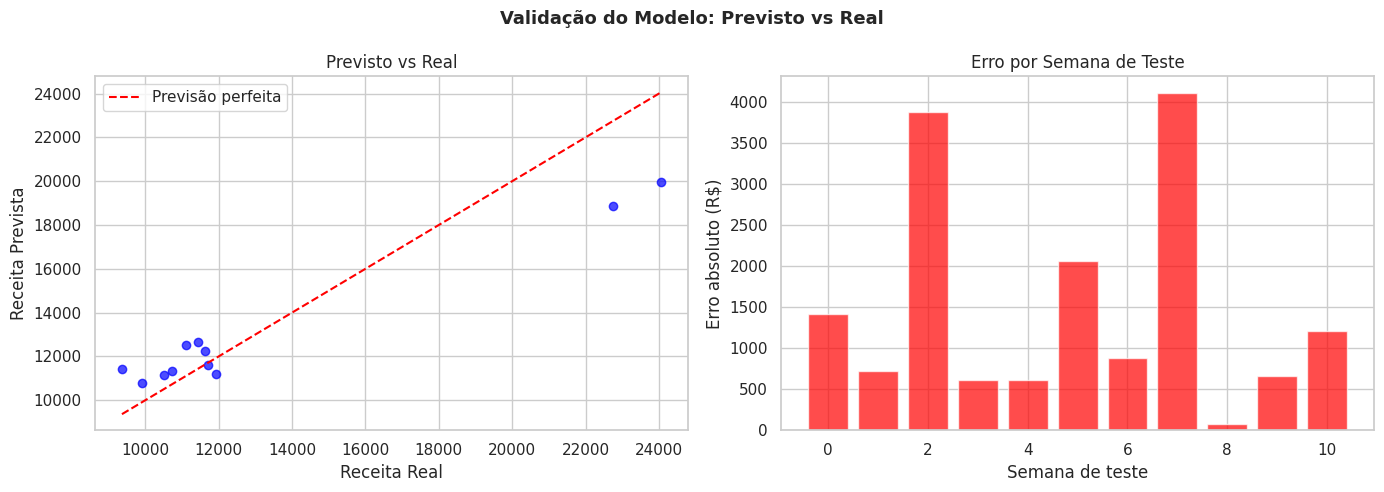

In [ ]:
# gráfico: previsto vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validação do Modelo: Previsto vs Real', fontsize=13, fontweight='bold')

# gráfico 1: scatter previsto vs real
axes[0].scatter(Y_teste, Y_previsto, color='blue', alpha=0.7)
axes[0].plot([Y_teste.min(), Y_teste.max()],
             [Y_teste.min(), Y_teste.max()],
             color='red', linestyle='--', linewidth=1.5, label='Previsão perfeita')
axes[0].set_xlabel('Receita Real')
axes[0].set_ylabel('Receita Prevista')
axes[0].set_title('Previsto vs Real')
axes[0].legend()

# gráfico 2: erro absoluto por semana
axes[1].bar(range(len(df_validacao)), df_validacao['erro_absoluto'], color='red', alpha=0.7)
axes[1].set_xlabel('Semana de teste')
axes[1].set_ylabel('Erro absoluto (R$)')
axes[1].set_title('Erro por Semana de Teste')

plt.tight_layout()
plt.show()

No scatter da esquerda, os pontos da esquerda (semanas normais, receita 10-12k reais) estão bem próximos da linha vermelha, de modo que o modelo acerta bem nessas semanas. Os dois pontos isolados na direita (receita 22-24k reais) estão abaixo da linha, indicando que o modelo subestima os picos de sazonalidade, prevendo 19k reais quando o real foi 22-24k reais.

No gráfico de barras da direita, as barras maiores (semanas 2, 6 e 7) são exatamente as semanas de novembro/dezembro que o modelo não consegue capturar bem.

## Interpretação dos resultados

Agora vamos ler os coeficientes do modelo e traduzir para linguagem de negócio.

####Gráfico do ROAS implícito por plataforma

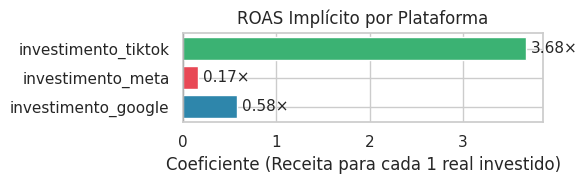

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2))

cores = ['#2E86AB', '#E84855', '#3BB273']
ax.barh(df_coeficientes['plataforma'], df_coeficientes['coeficiente'], color=cores)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (Receita para cada 1 real investido)')
ax.set_title('ROAS Implícito por Plataforma')

for i, (val, nome) in enumerate(zip(df_coeficientes['coeficiente'], df_coeficientes['plataforma'])):
    ax.text(val + 0.05, i, f'{val:.2f}×', va='center', fontsize=11)

plt.tight_layout()
plt.show()

####Gráfico da contribuição média semanal por plataforma

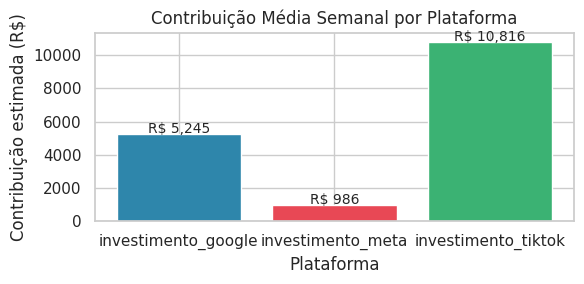

In [ ]:
investimento_medio = X.mean()
contribuicao = investimento_medio * modelo.coef_

df_contribuicao = pd.DataFrame({'plataforma': X.columns.tolist(),'contribuicao_estimada': contribuicao.round(2)})

fig, ax = plt.subplots(figsize=(6, 3))

ax.bar(df_contribuicao['plataforma'], df_contribuicao['contribuicao_estimada'], color=cores)
ax.set_xlabel('Plataforma')
ax.set_ylabel('Contribuição estimada (R$)')
ax.set_title('Contribuição Média Semanal por Plataforma')

for i, val in enumerate(df_contribuicao['contribuicao_estimada']):
    ax.text(i, val + 50, f'R$ {val:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Tabela resumo

In [ ]:
# tabela resumo
print("\nResumo por plataforma:")
df_resumo = pd.DataFrame({
    'plataforma': X.columns.tolist(),
    'investimento_medio_semanal': investimento_medio.round(2).values,
    'coeficiente_roas': modelo.coef_.round(4),
    'contribuicao_media_semanal': contribuicao.round(2).values
})
print(df_resumo)
print(f"\nReceita base estimada (sem mídia): R$ {modelo.intercept_:.2f}")
print(f"Receita total média semanal: R$ {df_modelo['receita'].mean():.2f}")


Resumo por plataforma:
            plataforma  investimento_medio_semanal  coeficiente_roas  \
0  investimento_google                     8988.89            0.5835   
1    investimento_meta                     5921.60            0.1666   
2  investimento_tiktok                     2941.96            3.6766   

   contribuicao_media_semanal  
0                     5245.20  
1                      986.46  
2                    10816.43  

Receita base estimada (sem mídia): R$ -4492.17
Receita total média semanal: R$ 12581.38


**Decomposição da receita média semanal:**

Com base nos coeficientes do modelo e no investimento médio de cada plataforma:

| Plataforma | Investimento médio semanal | ROAS implícito | Contribuição estimada |
|------------|---------------------------|----------------|----------------------|
| Google     | 8.989                  | 0,58×          | 5.245             |
| Meta       | 5.922                  | 0,17×          | 986               |
| TikTok     | 2.942                  | 3,68×          | 10.816            |


Apesar de receber o menor investimento entre as três plataformas, o TikTok
apresenta o maior ROAS implícito (3,68×) e a maior contribuição estimada
para a receita (10.816/semana). O Google, com o maior investimento,
apresenta o menor ROAS implícito (0,58×).

Esse resultado sugere uma oportunidade de redistribuição de orçamento:
aumentar o investimento no TikTok e reduzir no Google poderia,
em tese, melhorar o retorno total. Porém, essa recomendação deve ser
interpretada com cautela dado o efeito da multicolinearidade nos coeficientes.

**Limitações e próximos passos:**

1. **Multicolinearidade:** as três plataformas seguem a mesma sazonalidade,
   dificultando a separação do efeito individual de cada canal. Próximo passo:
   incluir variável de sazonalidade explícita.

2. **Dados sintéticos:** os dados foram gerados artificialmente. Com dados reais,  padrões mais complexos emergiriam e exigiriam modelos mais sofisticados.

3. **Incrementality:** os coeficientes estimam contribuição, não causalidade.
   Para medir o efeito incremental real de cada canal, seria necessário um
   experimento controlado.
